# One dimensional dummy problem

## Problem Statement

In this section the goal will be to solve the 1 dimensional dummy problem for a first step to pressure gradients

\begin{equation}
\begin{aligned}
\rho \partial_t v &=-RT\partial_x\rho+\mu\partial_x^2 v \\
\partial_t\rho&=-\partial_x (\rho v)
\end{aligned}
\end{equation}

under IC:

\begin{equation}
\left\{ \begin{aligned}
\rho(x,0) &= 1 \\
v(x,0) &= 0
\end{aligned}\right.
\end{equation}

and BC:
\begin{equation}
\left\{\begin{aligned}
\rho(0,t) &= 2-e^{-10t} \\
\partial_x v(0,t) &= 0 \\
v(L,t) &= 0
\end{aligned}\right.
\end{equation}

We will expand $\rho$, and $v$ as:

\begin{equation}
    \begin{aligned}
    \rho(x,t) &= \sum_i \rho_i(t) \phi^i(x) \\
    v(x,t) &= \sum_j v_j(t) \phi^j(x)
    \end{aligned}
\end{equation}

with our solutionvector:

\begin{equation}
    \mathbf u = \begin{pmatrix}
    \rho_1 \\ \vdots \\ \rho_{N_1} \\ v_1 \\ \vdots \\ v_{N_2}
    \end{pmatrix}
\end{equation}

### Mathematical Discretizations

If we look at the top part equation and multiply by test functions $\phi^k$, integrate and expand as above, we get:

\begin{equation}
    \sum_j\left(\sum_i\rho_i\int_\Omega \phi^i\phi^j\phi^k\,dx\right)(\partial_t \mathbf{u})
\end{equation}

Which becomes:

\begin{equation}
    M\dot{\mathbf{u}}
\end{equation}

where row $k$ and column $j$ correspond to:

\begin{equation}
    (M_v)_{kj} = \sum_i\rho_i\int \phi^i\phi^j\phi^k\,dx
\end{equation}
I plan on precalculating the integrals into a tensor:

\begin{equation}
    T_{ijk} = \int \phi^i\phi^j\phi^k\,dx
\end{equation}
simplifying:
\begin{equation}
(M_v)_{kj}=\sum_i \rho_iT_{ijk}
\end{equation}

For the RHS of the first equation we get (after integration and multiplying by $\phi^k$) term for term:

\begin{equation}
\begin{aligned}
    -RT\sum_i\left(\int \phi^k\phi^i\,dx\right)\rho_i &= P\mathbf{\rho}\\
    -\mu\sum_i\left(\int\partial_x\phi^k\partial_x\phi^i\,dx\right) v_i &= D\mathbf{v}
\end{aligned}
\end{equation}

Giving us:

\begin{equation}
    M_v(\rho) \dot{\mathbf{v}}=P\mathbf{\rho}+D\mathbf{v}
\end{equation}


Now for the conservation of mass equation, the LHS becomes:
\begin{equation}
\sum_i\left(\int\phi^i\phi^k\,dx\right)(\partial_t\rho_i)=M_\rho\dot{\mathbf{u}}
\end{equation}

and the RHS becomes:
\begin{equation}
    -\int\phi^k\partial_x(\rho v)dx = -\left[ \phi^k\rho v\right]_{x\in\delta\Omega}+\int(\partial_x\phi^k)v \rho\, dx =\mathbf{N}(\rho, v)
\end{equation}

### IMEX Scheme

I want to use a similar IMEX Scheme as I did in section 1.
Previously I had solved one with an IMEX scheme, where all linear parts were taken implicit, and non-linear parts explicit. Having

\begin{equation}
\begin{aligned}
M_v(\rho)\dot{v}&=P\rho+Dv \\
M_{\rho}\dot{\rho}&=N(\rho, v)+BF
\end{aligned}
\end{equation}

Is it now again posible to IMEX scheme like:

\begin{equation}
\begin{aligned}
M_v(\rho^n)\frac{v^{n+1}-v^n}{\Delta t}&=P\rho^{n+1}+Dv^{n+1} \\
M_{\rho}\frac{\rho^{n+1}-\rho^n}{\Delta t}&=N(\rho^n, v^n)+BF^n
\end{aligned}
\end{equation}

which gives:

\begin{equation}
\begin{aligned}
\frac{M_{\rho}}{\Delta t}{\rho^{n+1}}&=N(\rho^n, v^n)+BF^n+\frac{M_{\rho}}{\Delta t}\rho^n \\
\left[\frac{M_v(\rho^n)}{\Delta t}-D\right]v^{n+1}-P\rho^{n+1}&=\frac{M_v(\rho^n)}{\Delta t}v^n
\end{aligned}
\end{equation}

which gives:

\begin{equation}
    Au^{n+1}=Bu^n+C
\end{equation}

where:

\begin{equation}
\begin{aligned}
    A &= \begin{pmatrix}
    \frac{M_{\rho}}{\Delta t} & 0 \\
    -P & \frac{M_v(\rho^n)}{\Delta t}-D
    \end{pmatrix}\\
    B &= \begin{pmatrix}
    \frac{M_{\rho}}{\Delta t} & 0 \\
    0 & \frac{M_v(\rho^n)}{\Delta t}
    \end{pmatrix}\\
    C &= \begin{pmatrix}
        N(\rho^n, v^n) \\ 0
    \end{pmatrix}\\
    (M_{\rho})_{ij}&=\int \phi^i\phi^j\,dx \\
    P_{ij} &= -RT\int\phi^i\partial_x\phi^j\,dx \\
    D_{ij} &= -\mu\int (\partial_x \phi^i)(\partial_x \phi^j)dx\\
    (M_v(\rho^n))_{kj}&=\sum_i\rho_i T_{kij} \\
    T_{ijk} &= \int \phi^i\phi^j\phi^k\,dx\\
    (N(\rho^n, v^n))_k&=-\big[\phi^k\rho v\big]_{\delta \Omega}+\int\partial_x(\phi^k)v\rho\,dx
\end{aligned}
\end{equation}

In [1]:
using Ferrite, SparseArrays, WriteVTK, Plots, LinearAlgebra

## Definitions

In [2]:
# Constants
dt = 5e-5
dt_save = 1e-1
T = 10.0;
R = 1.0;
μ = 1.0;

name = "a. one dimensional fem";

save_every = Int(round(dt_save / dt))  # = 100 steps
nsteps = Int(round(T / dt_save))

100

## grid

In [3]:
# generates grid
grid = generate_grid(Line, (200,), Vec((0.0,)), Vec((1.0,)))

# generate the same 
qr = QuadratureRule{RefLine}(2)
fr = FacetQuadratureRule{RefLine}

ip_rho = Lagrange{RefLine, 1}()
cellvalues_rho = CellValues(qr, ip_rho);

ip_v = Lagrange{RefLine, 1}()
cellvalues_v = CellValues(qr, ip_v);

ip_f = Lagrange{RefLine, 1}()
fqr = FacetQuadratureRule{RefLine}(1)
facetvalues = FacetValues(Float64, fqr, ip_f)

left =  getfacetset(grid, "left")
right = getfacetset(grid, "right")



OrderedCollections.OrderedSet{FacetIndex} with 1 element:
  FacetIndex((200, 2))

In [4]:
# degree of freedom handler
dh = DofHandler(grid)
add!(dh, :rho, ip_rho)
add!(dh, :v,   ip_v)
close!(dh);

In [5]:
# constraint handler
ch = ConstraintHandler(dh)

inlet_ρ = Dirichlet(
    :rho,
    left,
    (x, t) -> 2-exp(-10*t)
)
right_v = Dirichlet(
    :v,
    right,
    (x, t) -> 0
)



add!(ch, inlet_ρ)
add!(ch, right_v)
close!(ch)
update!(ch, 0.0)

In [6]:
# for debugging purpuses

const rho_global = unique(sort(vcat([
    celldofs(cell)[dof_range(dh,:rho)]
    for cell in CellIterator(dh)
]...)))

const v_global = unique(sort(vcat([
    celldofs(cell)[dof_range(dh,:v)]
    for cell in CellIterator(dh)
]...)));

$$(M_{\rho})_{ij}=\int \phi^i\phi^j\,dx$$

In [7]:
function doassemble_M_rho!(
    M_rho::SparseMatrixCSC, 
    cellvalues_rho::CellValues, 
    dh::DofHandler
    )

    # number of basis functions per field, initialize Me
    n_basefuncs_rho  = getnbasefunctions(cellvalues_rho)
    first_cell = first(CellIterator(dh))
    ndofs_cell = length(celldofs(first_cell))
    Me = zeros(ndofs_cell, ndofs_cell)

    
    assembler = start_assemble(M_rho)
    rho_dofs = dof_range(dh, :rho)

    # loop over all cells
    for cell in CellIterator(dh)

        # get local dofs of this cell for rho
        cell_dofs = celldofs(cell)
        fill!(Me,0)
        
        reinit!(cellvalues_rho, cell)

        for q_point in 1:getnquadpoints(cellvalues_rho)
            dx = getdetJdV(cellvalues_rho, q_point)

            for i in 1:n_basefuncs_rho
                psi_i = shape_value(cellvalues_rho, q_point, i)

                for j in 1:n_basefuncs_rho
                    psi_j = shape_value(cellvalues_rho, q_point, j)

                    # pim pam pet
                    Me[rho_dofs[i], rho_dofs[j]] += psi_i * psi_j * dx
                end
            end
        end

        assemble!(assembler, cell_dofs, Me)
    end
    return M_rho
end


doassemble_M_rho! (generic function with 1 method)

$$D_{ij} = -\mu\int (\partial_x \phi^i)(\partial_x \phi^j)dx$$

In [8]:
function doassemble_D!(
    D::SparseMatrixCSC, 
    cellvalues_v::CellValues, 
    dh::DofHandler
    )

    # number of basis functions per field
    n_basefuncs_v  = getnbasefunctions(cellvalues_v)
    first_cell = first(CellIterator(dh))
    ndofs_cell = length(celldofs(first_cell))
    De = zeros(ndofs_cell, ndofs_cell)

    
    assembler = start_assemble(D)
    v_dofs = dof_range(dh, :v)
    # loop over all cells
    for cell in CellIterator(dh)

        # get local dofs of this cell for v
        cell_dofs = celldofs(cell)
        fill!(De,0)
        
        reinit!(cellvalues_v, cell)

        for q_point in 1:getnquadpoints(cellvalues_v)
            dx = getdetJdV(cellvalues_v, q_point)

            for i in 1:n_basefuncs_v
                dpsi_i = shape_gradient(cellvalues_v, q_point, i)

                for j in 1:n_basefuncs_v
                    dpsi_j = shape_gradient(cellvalues_v, q_point, j)

                    De[v_dofs[i], v_dofs[j]] += -μ * dot(dpsi_i, dpsi_j) * dx
                end
            end
        end

        assemble!(assembler, cell_dofs, De)
    end
    return D
end


doassemble_D! (generic function with 1 method)

$$D^p_{ij} = -\epsilon\int (\partial_x \phi^i)(\partial_x \phi^j)dx$$

In [9]:
function doassemble_Dp!(
    Dp::SparseMatrixCSC, 
    cellvalues_rho::CellValues, 
    dh::DofHandler
    )

    # number of basis functions per field
    n_basefuncs_rho  = getnbasefunctions(cellvalues_rho)
    first_cell = first(CellIterator(dh))
    ndofs_cell = length(celldofs(first_cell))
    Dpe = zeros(ndofs_cell, ndofs_cell)

    
    assembler = start_assemble(Dp)
    rho_dofs = dof_range(dh, :rho)
    # loop over all cells
    for cell in CellIterator(dh)

        # get local dofs of this cell for v
        cell_dofs = celldofs(cell)
        fill!(Dpe,0)
        
        reinit!(cellvalues_rho, cell)

        for q_point in 1:getnquadpoints(cellvalues_rho)
            dx = getdetJdV(cellvalues_rho, q_point)

            for i in 1:n_basefuncs_rho
                dpsi_i = shape_gradient(cellvalues_rho, q_point, i)

                for j in 1:n_basefuncs_rho
                    dpsi_j = shape_gradient(cellvalues_rho, q_point, j)

                    Dpe[rho_dofs[i], rho_dofs[j]] += -0.001 * dot(dpsi_i, dpsi_j) * dx
                end
            end
        end

        assemble!(assembler, cell_dofs, Dpe)
    end
    return Dp
end


doassemble_Dp! (generic function with 1 method)

$$P_{ij} = -RT\int\phi^i\partial_x\phi^j\,dx$$

In [10]:
function doassemble_P!(
    P::SparseMatrixCSC, 
    cellvalues_v::CellValues, 
    cellvalues_ρ:: CellValues,
    dh::DofHandler
    )

    # number of basis functions per field
    n_basefuncs_v  = getnbasefunctions(cellvalues_v)
    n_basefuncs_ρ  = getnbasefunctions(cellvalues_ρ)
    
    first_cell = first(CellIterator(dh))
    ndofs_cell = length(celldofs(first_cell))
    Pe = zeros(ndofs_cell, ndofs_cell)

    
    assembler = start_assemble(P)
    v_dofs = dof_range(dh, :v)
    rho_dofs = dof_range(dh, :rho)

    # loop over all cells
    for cell in CellIterator(dh)

        # get local dofs of this cell for v
        cell_dofs = celldofs(cell)
        fill!(Pe,0)

        reinit!(cellvalues_v, cell)
        reinit!(cellvalues_ρ, cell)

        for q in 1:getnquadpoints(cellvalues_v)

            dx = getdetJdV(cellvalues_v, q)

            for k in 1:n_basefuncs_v

                phi_k = shape_value(cellvalues_v, q, k)

                for j in 1:n_basefuncs_ρ

                    dpsi_j = shape_gradient(cellvalues_ρ, q, j)

                    Pe[v_dofs[k], rho_dofs[j]] +=
                        -R*T * phi_k * dpsi_j[1] * dx
                end
            end
        end

        assemble!(assembler, cell_dofs, Pe)
    end
    return P
end

doassemble_P! (generic function with 1 method)

$$(M_v(\rho^n))_{kj}=\sum_i\rho_i T_{kij} $$

$$T_{ijk} = \int \phi^i\phi^j\phi^k\,dx$$

$$(M_v(\rho^n))_{kj}=\int\rho_h^n\phi^j\phi^k\,dx  $$

In [11]:
function doassemble_M_v!(
        M_v::SparseMatrixCSC,
        u::Vector{Float64},
        cellvalues_rho::CellValues,
        cellvalues_v::CellValues,
        dh::DofHandler
    )

    # number of basis functions per field
    n_basefuncs_v  = getnbasefunctions(cellvalues_v)
    n_basefuncs_rho  = getnbasefunctions(cellvalues_rho)
    
    first_cell = first(CellIterator(dh))
    ndofs_cell = length(celldofs(first_cell))
    M_ve = zeros(ndofs_cell, ndofs_cell)

    assembler = start_assemble(M_v)
    v_dofs = dof_range(dh, :v)
    rho_dofs = dof_range(dh, :rho)

    # loop over all cells
    for cell in CellIterator(dh)    
        # get local dofs of this cell for v
        cell_dofs = celldofs(cell)
        rho_local = u[cell_dofs[rho_dofs]]

        fill!(M_ve,0)

        reinit!(cellvalues_v, cell)
        reinit!(cellvalues_rho, cell) 

        for q in 1:getnquadpoints(cellvalues_v)
            rho_q = sum(
                rho_local[j] *
                shape_value(cellvalues_rho,q,j)
                for j in 1:n_basefuncs_rho
            )

            # below alternate way that might be quicker?
            # rho_q = 0.0
            # for j in 1:n_basefuncs_rho
            #     rho_q += rho_local[j] *
            #             shape_value(cellvalues_rho,q,j)
            # end

            dx = getdetJdV(cellvalues_v, q)

            for k in 1:n_basefuncs_v
                psi_k = shape_value(
                    cellvalues_v,
                    q,
                    k
                )
                for i in 1:n_basefuncs_v
                    psi_i = shape_value(
                        cellvalues_v,
                        q,
                        i
                    )
                        
                    M_ve[v_dofs[k], v_dofs[i]] += rho_q*psi_k*psi_i*dx
                end
            end
        end
        assemble!(assembler, cell_dofs, M_ve)
    end
    return M_v
end

doassemble_M_v! (generic function with 1 method)

$$(N(\rho^n, v^n))_k=-\big[\phi^k\rho v\big]_{\delta \Omega}+\int\partial_x(\phi^k)v\rho\,dx$$

$$-\big[\phi^k\rho v\big]_{\delta \Omega} = \phi^k(0)v(0)\rho(0)$$

In [12]:
function doassemble_N!(
        N::Vector{Float64},
        u::Vector{Float64},
        cellvalues_rho::CellValues,
        cellvalues_v::CellValues,
        facetvalues::FacetValues,
        left,
        dh::DofHandler
    )
    
    # number of basis functions per field
    n_basefuncs_v  = getnbasefunctions(cellvalues_v)
    n_basefuncs_rho  = getnbasefunctions(cellvalues_rho)
    
    first_cell = first(CellIterator(dh))
    ndofs_cell = length(celldofs(first_cell))
    fill!(N, 0.0)

    v_dofs = dof_range(dh, :v)
    rho_dofs = dof_range(dh, :rho)

    for cell in CellIterator(dh)
        cell_dofs = celldofs(cell)
        rho_local = u[cell_dofs[rho_dofs]]
        v_local   = u[cell_dofs[v_dofs]]

        reinit!(cellvalues_rho, cell)
        reinit!(cellvalues_v, cell)

        for q in 1:getnquadpoints(cellvalues_rho)

            dx = getdetJdV(cellvalues_rho, q)

            rho_q = sum(
                rho_local[j] *
                shape_value(cellvalues_rho,q,j)
                for j in 1:n_basefuncs_rho
            )
            v_q = sum(
                v_local[j] *
                shape_value(cellvalues_v,q,j)
                for j in 1:n_basefuncs_rho
            )                        
            for k in 1:n_basefuncs_rho
                dpsi_k = shape_gradient(
                    cellvalues_rho,
                    q,
                    k
                )
                N[cell_dofs[rho_dofs[k]]] += dpsi_k[1] * v_q * rho_q * dx
            end
        end
    end

    # left-boundary term: v rho ϕ^k |_{x=0}
    for facet in FacetIterator(dh, left)
        reinit!(facetvalues, facet)

        facet_dofs = facet.dofs
        rho_local = u[facet_dofs[rho_dofs]]
        v_local = u[facet_dofs[v_dofs]]

        for q in 1:getnquadpoints(facetvalues)

            dborder = getdetJdV(facetvalues, q)
            rho_q = sum(
                rho_local[j] *
                shape_value(facetvalues,q,j)
                for j in 1:n_basefuncs_rho
            )
            v_q = sum(
                v_local[j] *
                shape_value(facetvalues,q,j)
                for j in 1:n_basefuncs_v
            )               

            for k in 1:n_basefuncs_rho
                psi_k = shape_value(
                    facetvalues, 
                    q, 
                    k
                )

                N[facet_dofs[rho_dofs[k]]] += v_q * rho_q * psi_k * dborder

            end
        end         
    end
    return N 
end
    # rho_bc = 2 - exp(-10*t)
    # v_left = u[first_velocity_dof]

    # N[first_density_dof] += rho_bc * v_left



doassemble_N! (generic function with 1 method)

In [13]:
struct RHSparams
    A::SparseMatrixCSC
    ch::ConstraintHandler
    dh::DofHandler
    cellvalues_rho::CellValues
    cellvalues_rhos::CellValues
    u::Vector
end

In [14]:
# Initialization of matrices

# Assemble linear matrices (ONCE)
M_rho = allocate_matrix(dh)
M_v   = allocate_matrix(dh)
D     = allocate_matrix(dh)
Dp    = allocate_matrix(dh)
P     = allocate_matrix(dh)

doassemble_M_rho!(M_rho, cellvalues_rho, dh)
doassemble_D!(D, cellvalues_v, dh)
doassemble_Dp!(Dp, cellvalues_rho, dh)
doassemble_P!(P, cellvalues_v, cellvalues_rho, dh)

# Linear parts
A_lin = -P - D -Dp + M_rho / dt
B_lin = M_rho / dt

# State vectors
ndofs_total = ndofs(dh)

u      = zeros(ndofs_total)
u_new  = similar(u)

rhs    = similar(u)

N      = zeros(ndofs_total)
M_v    = allocate_matrix(dh)

# Initial condition
apply_analytical!(u, dh, :rho, x -> 1.0)
apply_analytical!(u, dh, :v,   x -> 0.0)

# Initial BC application (IMPORTANT)
update!(ch, 0.0)
apply!(u, ch)

# Optional: verify initial consistency
fill!(M_v, 0.0)
fill!(N, 0.0)

doassemble_M_v!(M_v, u, cellvalues_rho, cellvalues_v, dh)
doassemble_N!(N, u, cellvalues_rho, cellvalues_v, facetvalues, left, dh)

println("Initial ||N|| = ", norm(N))

Initial ||N|| = 0.0


In [15]:
# IMEX loop

u_all = zeros(ndofs(dh), nsteps)
step_save = 0

for (step, t) in enumerate(dt:dt:T)

    # 1. Update BCs
    update!(ch, t)

    # 2. Reset nonlinear terms
    fill!(M_v, 0.0)
    fill!(N, 0.0)

    doassemble_M_v!(M_v, u, cellvalues_rho, cellvalues_v, dh)
    doassemble_N!(N, u, cellvalues_rho, cellvalues_v, facetvalues, left, dh)

    # 3. Build system matrices fresh
    A = copy(A_lin)
    B = copy(B_lin)

    A .+= M_v ./ dt
    B .+= M_v ./ dt

    rhs = similar(u)
    rhs .= B * u .+ N

    # 4. Apply BCs consistently
    rhsdata = get_rhs_data(ch, A)

    A_bc = copy(A)
    rhs_bc = copy(rhs)

    apply!(A_bc, ch)
    apply_rhs!(rhsdata, rhs_bc, ch)

    # 5. Solve
    u_new = A_bc \ rhs_bc

    apply!(u_new, ch)

    # 6. Store + advance
    u = u_new
    # SAVE ONLY EVERY dt_save
    if step % save_every == 0
        step_save += 1
        u_all[:, step_save] .= u
        println(step_save*dt_save)
    end
end

0.1
0.2
0.30000000000000004
0.4
0.5
0.6000000000000001
0.7000000000000001
0.8
0.9
1.0
1.1
1.2000000000000002
1.3
1.4000000000000001
1.5
1.6
1.7000000000000002
1.8
1.9000000000000001
2.0
2.1
2.2
2.3000000000000003
2.4000000000000004
2.5
2.6
2.7
2.8000000000000003
2.9000000000000004
3.0
3.1
3.2
3.3000000000000003
3.4000000000000004
3.5
3.6
3.7
3.8000000000000003
3.9000000000000004
4.0
4.1000000000000005
4.2
4.3
4.4
4.5
4.6000000000000005
4.7
4.800000000000001
4.9
5.0
5.1000000000000005
5.2
5.300000000000001
5.4
5.5
5.6000000000000005
5.7
5.800000000000001
5.9
6.0
6.1000000000000005
6.2
6.300000000000001
6.4
6.5
6.6000000000000005
6.7
6.800000000000001
6.9
7.0
7.1000000000000005
7.2
7.300000000000001
7.4
7.5
7.6000000000000005
7.7
7.800000000000001
7.9
8.0
8.1
8.200000000000001
8.3
8.4
8.5
8.6
8.700000000000001
8.8
8.9
9.0
9.1
9.200000000000001
9.3
9.4
9.5
9.600000000000001
9.700000000000001
9.8
9.9
10.0


## Plotting/animating

In [15]:
using WriteVTK

In [ ]:
foldername = "debug"
filename = "test"
pvd = paraview_collection(joinpath(foldername, filename))

for (step, t) in enumerate(dt_save:dt_save:T)
    u = u_all[:, step]
    VTKGridFile(joinpath(foldername, "$(filename)-$step"), dh) do vtk
        write_solution(vtk, dh, u)
        pvd[t] = vtk
    end
end
vtk_save(pvd);

In [16]:
using Plots

[ Info: Saved animation to c:\Users\noudh\uni\MEP\4. fem model two\a. one dimensional fem\flow_higher_def.gif


Plots.AnimatedGif("c:\\Users\\noudh\\uni\\MEP\\4. fem model two\\a. one dimensional fem\\flow_higher_def.gif")
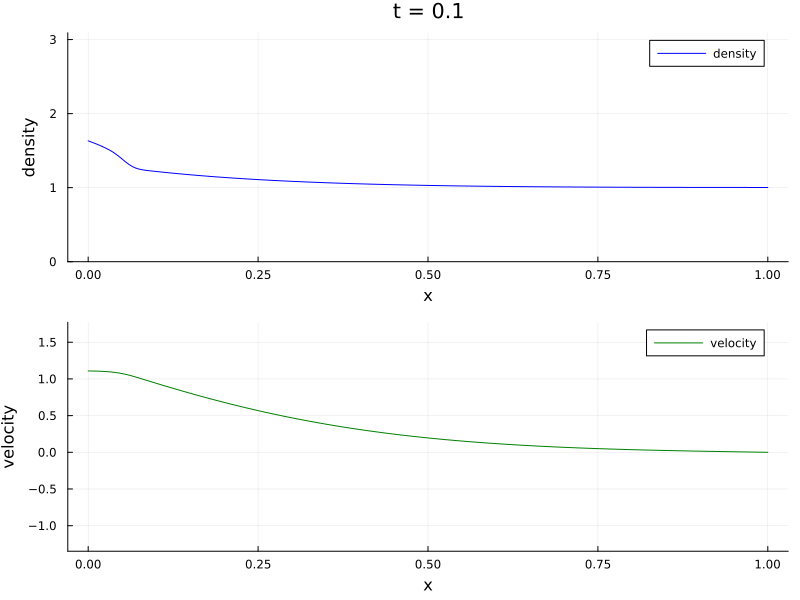

In [17]:
# double gif plot
foldername = name
sol_ρ = u_all[rho_global, :]
sol_v = u_all[v_global, :]

discrete_x = range(0.0, 1.0, length=size(sol_ρ, 1))
discrete_t = range(dt_save, step=dt_save, length=size(sol_ρ, 2))

ρmax = maximum(sol_ρ)
ρmin = minimum(sol_ρ)

vmax = maximum(sol_v)
vmin = minimum(sol_v)

anim = @animate for k in 1:size(sol_ρ, 2)

    p1 = plot(
        discrete_x,
        sol_ρ[:, k],
        label="density",
        color=:blue,
        xlabel="x",
        ylabel="density",
        title="t = $(round(discrete_t[k], digits=3))",
        ylims=(0, ρmax),
        legend=:topright
    )

    p2 = plot(
        discrete_x,
        sol_v[:, k],
        label="velocity",
        color=:green,
        xlabel="x",
        ylabel="velocity",
        ylims=(vmin, vmax),
        legend=:topright
    )

    plot(p1, p2, layout=(2,1), size=(800,600))
end

gif(anim, joinpath(foldername, "flow_higher_def.gif"), fps=10)

### Ugly plots below

# Debugging

In [ ]:
# debugging
doassemble_M_v!(M_v, u, cellvalues_rho, cellvalues_v, dh)
doassemble_N!(N, u, cellvalues_rho, cellvalues_v, facetvalues, left, dh)

In [18]:
# debugging
display(Matrix(M_rho[rho_global, rho_global]))
display(Matrix(D[v_global, v_global]))
display(Matrix(P[
    v_global ,
    rho_global
    ]))
display(Matrix(M_v[v_global, v_global]))

201×201 Matrix{Float64}:
 0.00166667   0.000833333  0.0          …  0.0          0.0
 0.000833333  0.00333333   0.000833333     0.0          0.0
 0.0          0.000833333  0.00333333      0.0          0.0
 0.0          0.0          0.000833333     0.0          0.0
 0.0          0.0          0.0             0.0          0.0
 0.0          0.0          0.0          …  0.0          0.0
 0.0          0.0          0.0             0.0          0.0
 0.0          0.0          0.0             0.0          0.0
 0.0          0.0          0.0             0.0          0.0
 0.0          0.0          0.0             0.0          0.0
 0.0          0.0          0.0          …  0.0          0.0
 0.0          0.0          0.0             0.0          0.0
 0.0          0.0          0.0             0.0          0.0
 ⋮                                      ⋱               ⋮
 0.0          0.0          0.0             0.0          0.0
 0.0          0.0          0.0          …  0.0          0.0
 0.0          0.0

201×201 Matrix{Float64}:
 -200.0   200.0     0.0     0.0     0.0  …     0.0     0.0     0.0     0.0
  200.0  -400.0   200.0     0.0     0.0        0.0     0.0     0.0     0.0
    0.0   200.0  -400.0   200.0     0.0        0.0     0.0     0.0     0.0
    0.0     0.0   200.0  -400.0   200.0        0.0     0.0     0.0     0.0
    0.0     0.0     0.0   200.0  -400.0        0.0     0.0     0.0     0.0
    0.0     0.0     0.0     0.0   200.0  …     0.0     0.0     0.0     0.0
    0.0     0.0     0.0     0.0     0.0        0.0     0.0     0.0     0.0
    0.0     0.0     0.0     0.0     0.0        0.0     0.0     0.0     0.0
    0.0     0.0     0.0     0.0     0.0        0.0     0.0     0.0     0.0
    0.0     0.0     0.0     0.0     0.0        0.0     0.0     0.0     0.0
    0.0     0.0     0.0     0.0     0.0  …     0.0     0.0     0.0     0.0
    0.0     0.0     0.0     0.0     0.0        0.0     0.0     0.0     0.0
    0.0     0.0     0.0     0.0     0.0        0.0     0.0     0.0     0.0


201×201 Matrix{Float64}:
 5.0  -5.0   0.0           0.0          …   0.0   0.0   0.0   0.0   0.0   0.0
 5.0   0.0  -5.0           0.0              0.0   0.0   0.0   0.0   0.0   0.0
 0.0   5.0  -8.88178e-16  -5.0              0.0   0.0   0.0   0.0   0.0   0.0
 0.0   0.0   5.0           8.88178e-16      0.0   0.0   0.0   0.0   0.0   0.0
 0.0   0.0   0.0           5.0              0.0   0.0   0.0   0.0   0.0   0.0
 0.0   0.0   0.0           0.0          …   0.0   0.0   0.0   0.0   0.0   0.0
 0.0   0.0   0.0           0.0              0.0   0.0   0.0   0.0   0.0   0.0
 0.0   0.0   0.0           0.0              0.0   0.0   0.0   0.0   0.0   0.0
 0.0   0.0   0.0           0.0              0.0   0.0   0.0   0.0   0.0   0.0
 0.0   0.0   0.0           0.0              0.0   0.0   0.0   0.0   0.0   0.0
 0.0   0.0   0.0           0.0          …   0.0   0.0   0.0   0.0   0.0   0.0
 0.0   0.0   0.0           0.0              0.0   0.0   0.0   0.0   0.0   0.0
 0.0   0.0   0.0           0.0         

201×201 Matrix{Float64}:
 0.00333333  0.00166667  0.0         …  0.0         0.0         0.0
 0.00166667  0.00666666  0.00166666     0.0         0.0         0.0
 0.0         0.00166666  0.00666664     0.0         0.0         0.0
 0.0         0.0         0.00166666     0.0         0.0         0.0
 0.0         0.0         0.0            0.0         0.0         0.0
 0.0         0.0         0.0         …  0.0         0.0         0.0
 0.0         0.0         0.0            0.0         0.0         0.0
 0.0         0.0         0.0            0.0         0.0         0.0
 0.0         0.0         0.0            0.0         0.0         0.0
 0.0         0.0         0.0            0.0         0.0         0.0
 0.0         0.0         0.0         …  0.0         0.0         0.0
 0.0         0.0         0.0            0.0         0.0         0.0
 0.0         0.0         0.0            0.0         0.0         0.0
 ⋮                                   ⋱                          ⋮
 0.0         0.0         

In [ ]:
# debugging

# --------------------------------------------------
# Assemble constant matrices
# --------------------------------------------------
M_rho = allocate_matrix(dh)
M_v   = allocate_matrix(dh)
D     = allocate_matrix(dh)
P     = allocate_matrix(dh)

doassemble_M_rho!(M_rho, cellvalues_rho, dh)
doassemble_D!(D, cellvalues_v, dh)
doassemble_P!(P, cellvalues_v, cellvalues_rho, dh)

A_lin = -P - D + M_rho/dt
B_lin = M_rho/dt

# --------------------------------------------------
# Initial condition
# --------------------------------------------------
ndofs_total = ndofs(dh)

u   = zeros(ndofs_total)
rhs = zeros(ndofs_total)
N   = zeros(ndofs_total)

apply_analytical!(u, dh, :rho, x -> 1.0)
apply_analytical!(u, dh, :v,   x -> 0.0)

update!(ch, 0.0)
apply!(u, ch)

println("Initial u:")
display(u)

# --------------------------------------------------
# Assemble nonlinear pieces at IC
# --------------------------------------------------
fill!(M_v, 0.0)
fill!(N, 0.0)

doassemble_M_v!(M_v, u, cellvalues_rho, cellvalues_v, dh)
doassemble_N!(N, u, cellvalues_rho, cellvalues_v,
              facetvalues, left, dh)

println("||N|| = ", norm(N))

# --------------------------------------------------
# Build system
# --------------------------------------------------
A = copy(A_lin)
B = copy(B_lin)

A .+= M_v/dt
B .+= M_v/dt

rhs .= B*u + N

println("norm(rhs) = ", norm(rhs))

# --------------------------------------------------
# Apply BCs
# --------------------------------------------------
update!(ch, dt)

rhsdata = get_rhs_data(ch, A)

A_bc   = copy(A)
rhs_bc = copy(rhs)

apply!(A_bc, ch)
apply_rhs!(rhsdata, rhs_bc, ch)

# --------------------------------------------------
# Diagnostics
# --------------------------------------------------
println("size(A) = ", size(A_bc))
println("rank estimate = ", rank(Matrix(A_bc)))

println("minimum diag(A) = ", minimum(diag(A_bc)))
println("maximum diag(A) = ", maximum(diag(A_bc)))

# --------------------------------------------------
# Solve ONE timestep
# --------------------------------------------------
u_new = A_bc \ rhs_bc

apply!(u_new, ch)

println("max |u_new-u| = ", maximum(abs.(u_new .- u)))

# --------------------------------------------------
# Check fields separately
# --------------------------------------------------
println("rho old:")
display(u[rho_global])

println("rho new:")
display(u_new[rho_global])

println("v old:")
display(u[v_global])

println("v new:")
display(u_new[v_global])